In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import ztest

In [2]:
data = pd.read_csv("D:/PY_ENV/datasets/Death_rates_for_suicide__by_sex__race__Hispanic_origin__and_age__United_States.csv")

In [3]:
#UNDERSTANDING THE DATASET
data.head

<bound method NDFrame.head of                     INDICATOR  \
0     Death rates for suicide   
1     Death rates for suicide   
2     Death rates for suicide   
3     Death rates for suicide   
4     Death rates for suicide   
...                       ...   
6385  Death rates for suicide   
6386  Death rates for suicide   
6387  Death rates for suicide   
6388  Death rates for suicide   
6389  Death rates for suicide   

                                                   UNIT  UNIT_NUM  \
0     Deaths per 100,000 resident population, age-ad...         1   
1     Deaths per 100,000 resident population, age-ad...         1   
2     Deaths per 100,000 resident population, age-ad...         1   
3     Deaths per 100,000 resident population, age-ad...         1   
4     Deaths per 100,000 resident population, age-ad...         1   
...                                                 ...       ...   
6385      Deaths per 100,000 resident population, crude         2   
6386      Deaths per 

In [4]:
data.tail

<bound method NDFrame.tail of                     INDICATOR  \
0     Death rates for suicide   
1     Death rates for suicide   
2     Death rates for suicide   
3     Death rates for suicide   
4     Death rates for suicide   
...                       ...   
6385  Death rates for suicide   
6386  Death rates for suicide   
6387  Death rates for suicide   
6388  Death rates for suicide   
6389  Death rates for suicide   

                                                   UNIT  UNIT_NUM  \
0     Deaths per 100,000 resident population, age-ad...         1   
1     Deaths per 100,000 resident population, age-ad...         1   
2     Deaths per 100,000 resident population, age-ad...         1   
3     Deaths per 100,000 resident population, age-ad...         1   
4     Deaths per 100,000 resident population, age-ad...         1   
...                                                 ...       ...   
6385      Deaths per 100,000 resident population, crude         2   
6386      Deaths per 

In [5]:
data.shape

(6390, 13)

In [6]:
data.describe()

,UNIT_NUM,STUB_NAME_NUM,STUB_LABEL_NUM,YEAR,YEAR_NUM,AGE_NUM,ESTIMATE
count,6390.000000,6390.000000,6390.000000,6390.000000,6390.000000,6390.000000,5484.000000
mean,1.872926,4.621909,4.686775,1997.525822,22.692019,2.712207,13.709810
std,0.333081,2.031777,1.829624,14.937451,12.286033,1.932280,11.531805
min,1.000000,0.000000,0.000000,1950.000000,1.000000,0.000000,0.300000
25%,2.000000,3.000000,3.230000,1988.000000,12.000000,0.000000,5.000000
50%,2.000000,5.000000,5.125100,1999.000000,23.000000,3.000000,10.500000
75%,2.000000,6.000000,6.153000,2009.000000,33.000000,4.100000,19.500000
max,2.000000,11.000000,7.235000,2018.000000,42.000000,6.000000,74.800000


In [7]:
data.columns

Index(['INDICATOR', 'UNIT', 'UNIT_NUM', 'STUB_NAME', 'STUB_NAME_NUM',
       'STUB_LABEL', 'STUB_LABEL_NUM', 'YEAR', 'YEAR_NUM', 'AGE', 'AGE_NUM',
       'ESTIMATE', 'FLAG'],
      dtype='object')

In [8]:
data.nunique()

INDICATOR           1
UNIT                2
UNIT_NUM            2
STUB_NAME          12
STUB_NAME_NUM      12
STUB_LABEL        161
STUB_LABEL_NUM    161
YEAR               42
YEAR_NUM           42
AGE                15
AGE_NUM            15
ESTIMATE          529
FLAG                2
dtype: int64

In [9]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6390 entries, 0 to 6389
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INDICATOR       6390 non-null   object 
 1   UNIT            6390 non-null   object 
 2   UNIT_NUM        6390 non-null   int64  
 3   STUB_NAME       6390 non-null   object 
 4   STUB_NAME_NUM   6390 non-null   int64  
 5   STUB_LABEL      6390 non-null   object 
 6   STUB_LABEL_NUM  6390 non-null   float64
 7   YEAR            6390 non-null   int64  
 8   YEAR_NUM        6390 non-null   int64  
 9   AGE             6390 non-null   object 
 10  AGE_NUM         6390 non-null   float64
 11  ESTIMATE        5484 non-null   float64
 12  FLAG            906 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 649.1+ KB


INDICATOR            0
UNIT                 0
UNIT_NUM             0
STUB_NAME            0
STUB_NAME_NUM        0
STUB_LABEL           0
STUB_LABEL_NUM       0
YEAR                 0
YEAR_NUM             0
AGE                  0
AGE_NUM              0
ESTIMATE           906
FLAG              5484
dtype: int64

In [10]:
#obejtive 1
#data cleaning
#droping the data that is not much usefull for our obejtives
data1 = data.drop(['INDICATOR','UNIT_NUM','STUB_NAME','FLAG','AGE_NUM','STUB_LABEL_NUM','YEAR_NUM','STUB_NAME_NUM'],axis=1)
data1.head

<bound method NDFrame.head of                                                    UNIT  \
0     Deaths per 100,000 resident population, age-ad...   
1     Deaths per 100,000 resident population, age-ad...   
2     Deaths per 100,000 resident population, age-ad...   
3     Deaths per 100,000 resident population, age-ad...   
4     Deaths per 100,000 resident population, age-ad...   
...                                                 ...   
6385      Deaths per 100,000 resident population, crude   
6386      Deaths per 100,000 resident population, crude   
6387      Deaths per 100,000 resident population, crude   
6388      Deaths per 100,000 resident population, crude   
6389      Deaths per 100,000 resident population, crude   

                                             STUB_LABEL  YEAR  \
0                                           All persons  1950   
1                                           All persons  1960   
2                                           All persons  1970   
3

In [11]:
#OBJECTIVE 2 data prepration
#spliting STUB_LABEL column in two distinct columns as SEX and RACE
split_columns = data1['STUB_LABEL'].str.split(':', expand=True)
data1['SEX'] = split_columns[0]  # Assign the first part (SEX)
data1['RACE'] = split_columns[1]  # Assign the second part (RACE)

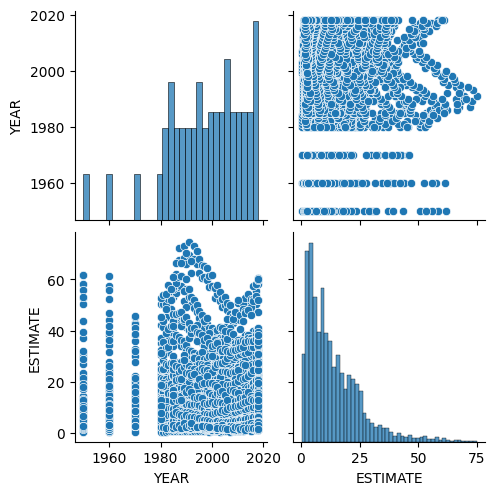

In [12]:
#OBJECTIVE 3
# Data Visualization
# Visualize Suicide trends using line plots, heatmaps, and box plots for better insights.
sns.pairplot(data1)

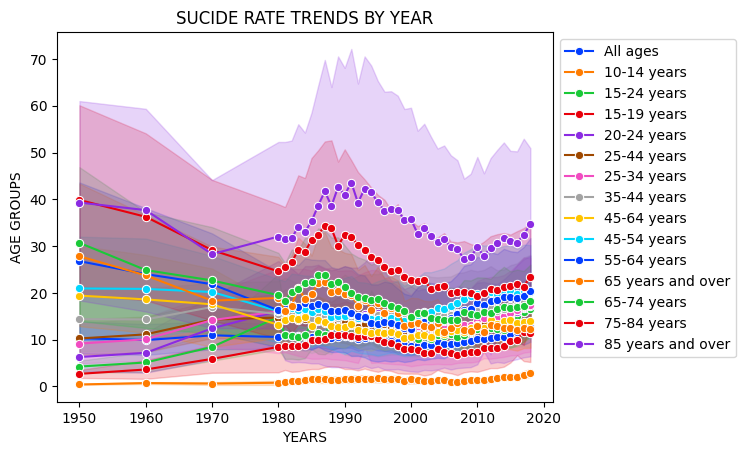

In [13]:
sns.lineplot(data=data1, x='YEAR', y='ESTIMATE', hue='AGE', marker='o', palette='bright')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('SUCIDE RATE TRENDS BY YEAR')
plt.xlabel('YEARS')
plt.ylabel('AGE GROUPS')

plt.show()

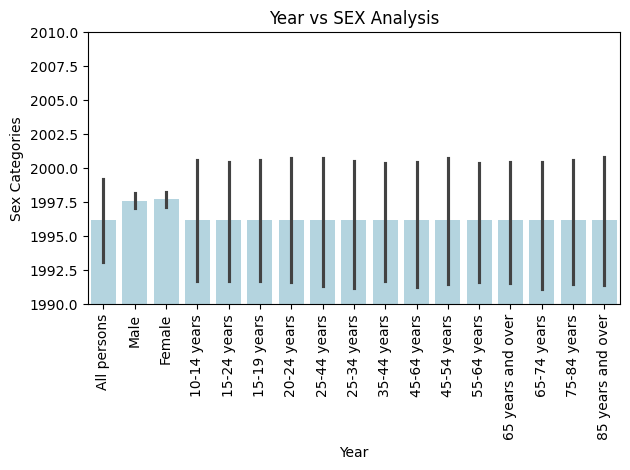

In [14]:
#BAR PLOT

sns.barplot(data=data1, x='SEX', y='YEAR', color='lightblue')

# Adjust x-axis limits
plt.ylim(1990, 2010)
plt.xticks(rotation=90)


# Add labels and title
plt.title('Year vs SEX Analysis')
plt.ylabel('Sex Categories')
plt.xlabel('Year')
plt.tight_layout()

plt.show()

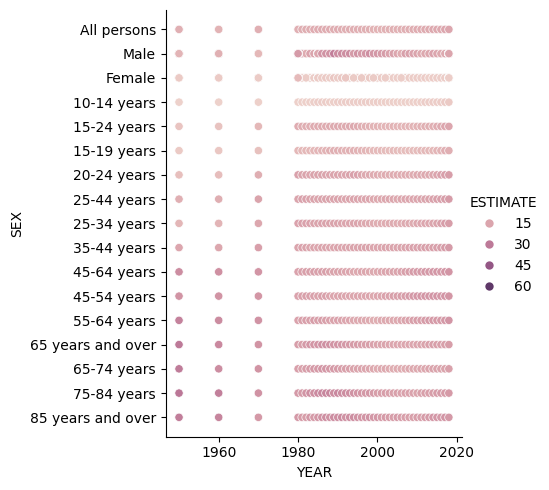

In [15]:
sns.relplot(x='YEAR', y='SEX', hue='ESTIMATE', data=data1)

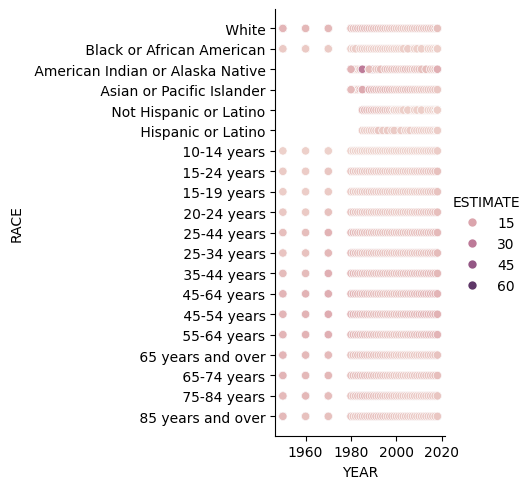

In [16]:
sns.relplot(x='YEAR', y='RACE', hue='ESTIMATE', data=data1)

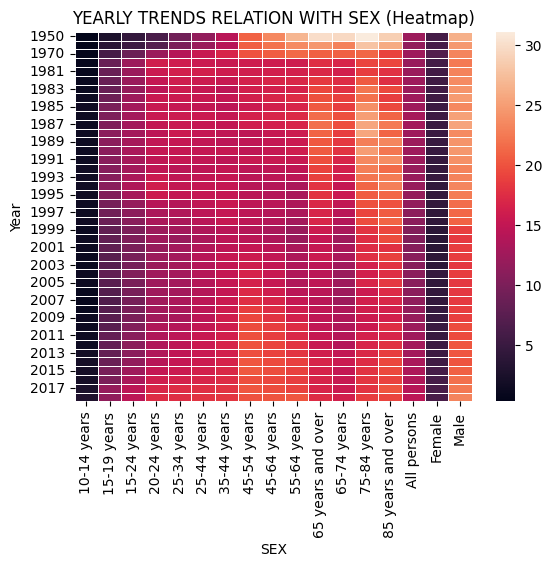

In [17]:
#HEATMAP
pivot_table = data1.groupby(['YEAR','SEX'])['ESTIMATE'].mean().unstack()



sns.heatmap(pivot_table, linewidths=0.5, linecolor='white')

plt.title('YEARLY TRENDS RELATION WITH SEX (Heatmap)')
plt.xlabel('SEX')
plt.ylabel('Year')
plt.show()

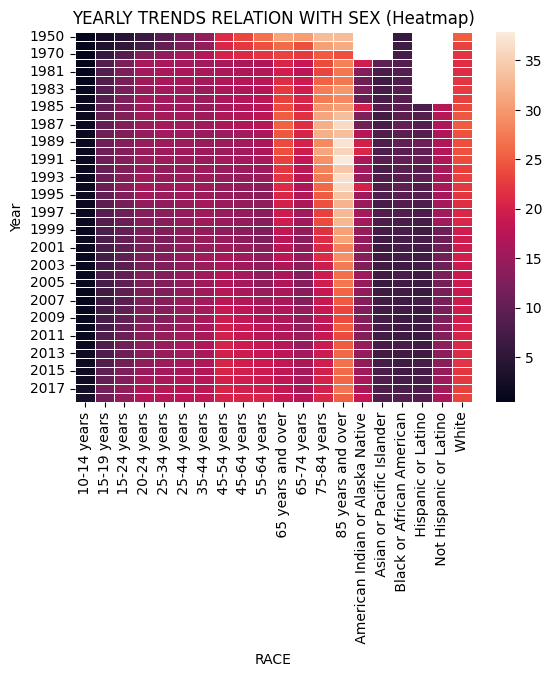

In [18]:
pivot_table = data1.groupby(['YEAR','RACE'])['ESTIMATE'].mean().unstack()



sns.heatmap(pivot_table, linewidths=0.5, linecolor='white')

plt.title('YEARLY TRENDS RELATION WITH SEX (Heatmap)')
plt.xlabel('RACE')
plt.ylabel('Year')
plt.show()

In [ ]:
#BOX PLOT

sns.boxplot(data1, x='YEAR', y='ESTIMATE', color='#ffc0cb')
plt.xticks(rotation=90)
plt.title(" YEARLY TRENDS")
plt.xlabel("ESTIMATE")
plt.ylabel("YEAR")
plt.show()


In [ ]:
#SCATTER PLOT

sns.scatterplot(data1, x='RACE', y='YEAR', hue='SEX')
plt.xticks(rotation=90)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title("")
plt.xlabel("YEAR")
plt.ylabel("RACE")
plt.show()

In [19]:
sns.distplot(data['']

_IncompleteInputError: incomplete input (2946797186.py, line 1)